In [3]:
import pandas as pd
import os 
import numpy as np
os.chdir("/users/nathanielborland/Documents/UVM/Classes/2025 Fall/Bayesian Statistics/Bayesketball/bayesketball") ## change to your root
os.getcwd()
import seaborn as sns
from matplotlib import pyplot as plt
import time
from scipy.stats import norm

#  scipy.stats.norm

# Setup

In [ ]:
posterior_samples = pd.read_csv("results/general_attempt_non_possession_posterior.csv")
posterior_samples

,alpha,beta[1],beta[2],beta[3],beta[4],beta[5],beta[6],beta[7],beta[8],beta[9],beta[10],sigma,lp__
0,0.063467,0.227715,0.260190,0.215144,-0.304742,1.535326,0.487665,0.154211,0.150482,-1.153945,-0.049539,6.241654,-52139.460847
1,0.147048,0.221054,0.258609,0.225107,-0.292311,1.513766,0.494151,0.155388,0.146749,-1.151707,-0.023941,6.119360,-52142.050577
2,0.095823,0.217741,0.255616,0.217182,-0.268458,1.526829,0.493757,0.145663,0.165732,-1.163450,-0.024781,6.194221,-52139.211923
3,0.093077,0.208708,0.259861,0.191610,-0.274059,1.538333,0.482537,0.177231,0.146409,-1.157545,-0.073111,6.202815,-52136.917516
4,0.019445,0.206207,0.268784,0.206965,-0.271986,1.542840,0.479100,0.151297,0.128976,-1.195197,-0.066914,6.175081,-52144.909987
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.146525,0.178357,0.264656,0.169626,-0.249646,1.530099,0.481711,0.160169,0.144036,-1.182823,-0.085716,6.216939,-52142.177128
1996,0.123870,0.191126,0.252642,0.189901,-0.247627,1.526948,0.492054,0.166515,0.125576,-1.180263,-0.059344,6.185180,-52138.154500
1997,0.127930,0.180718,0.251383,0.188598,-0.242933,1.529133,0.491508,0.158798,0.136201,-1.194515,-0.046874,6.186708,-52137.628116
1998,0.030097,0.177837,0.262825,0.195586,-0.244988,1.528454,0.494497,0.142036,0.120915,-1.201989,-0.055731,6.149135,-52140.187674


In [9]:
test_x_h = pd.read_csv("data/general_attempt_non_possession/x_h_test.csv")
test_x_a = pd.read_csv("data/general_attempt_non_possession/x_a_test.csv")
test_y  = pd.read_csv("data/general_attempt_non_possession/y_test.csv")
home_cols, away_cols = test_x_h.columns, test_x_a.columns

In [10]:
df = pd.concat([test_x_h, test_x_a, test_y], axis=1)

In [11]:
posterior_samples['alpha'].mean()

np.float64(0.09387936662253296)

In [12]:
def predict_diff_sigma(posterior_samples, home_cols, away_cols, df, y):
    betas = [f"beta[{i}]" for i in range(1, 11)]
    betas = posterior_samples[betas].mean().to_numpy()
    alpha = posterior_samples['alpha'].mean()
    
    df['home_weighted'] = df[home_cols].apply(lambda row: np.dot(betas, row), axis=1)
    df['away_weighted'] = df[away_cols].apply(lambda row: np.dot(betas, row), axis=1)
    df['mu'] = alpha + df['home_weighted'] - df['away_weighted']
    df['sigma' ] = posterior_samples['sigma'].mean()
    df['diff'] = y['plus_minus_home']
    return df

df = predict_diff_sigma(posterior_samples, home_cols, away_cols, df, test_y)
df.head()


,fga_home,fg3a_home,fta_home,oreb_home,dreb_home,ast_home,stl_home,blk_home,tov_home,pf_home,...,stl_away,blk_away,tov_away,pf_away,plus_minus_home,home_weighted,away_weighted,mu,sigma,diff
0,80.0,32.0,25.0,5.0,28.0,27.0,5.0,6.0,11.0,21.0,...,4.0,9.0,8.0,21.0,-16,71.972168,94.554801,-22.488753,6.178915,-16
1,88.0,14.0,23.0,17.0,28.0,20.0,13.0,7.0,10.0,20.0,...,4.0,6.0,19.0,25.0,8,64.537212,57.104656,7.526435,6.178915,8
2,90.0,36.0,24.0,12.0,31.0,25.0,4.0,2.0,15.0,19.0,...,9.0,4.0,10.0,19.0,5,71.266530,72.995436,-1.635027,6.178915,5
3,69.0,18.0,29.0,12.0,28.0,13.0,1.0,3.0,15.0,19.0,...,11.0,4.0,6.0,24.0,-27,52.544817,71.378636,-18.739939,6.178915,-27
4,68.0,22.0,60.0,8.0,35.0,26.0,7.0,8.0,17.0,31.0,...,6.0,8.0,11.0,41.0,7,76.442458,70.800833,5.735505,6.178915,7


# Single Game Analysis

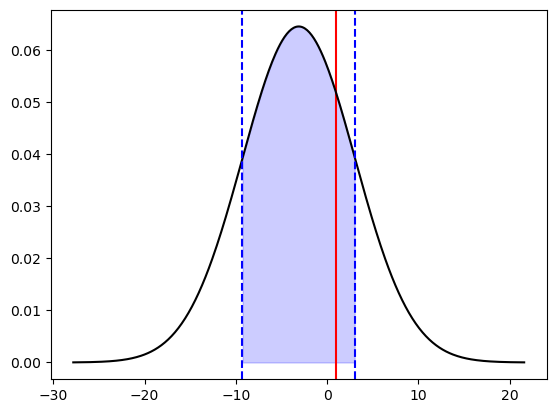

In [88]:
def plot_predict_sigma(df, y, idx, hist=True):
    row  = df.iloc[idx]
    mu = row['mu']
    sigma = row['sigma']
   


    plt.axvline(y.iloc[idx]['plus_minus_home'], color='red')
    if hist:
        samples = np.random.normal(mu, sigma, 2500)
        sns.histplot(samples)
    else:
        x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
        pdf = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-(x - mu)**2 / (2*sigma**2))
        plt.plot(x, pdf, color='black')
        plt.fill_between(x, pdf, 0, where=(x >= mu - sigma) & (x <= mu + sigma), color='blue', alpha=0.2)


    plt.axvline(mu - sigma, color='blue', linestyle='--')
    plt.axvline(mu + sigma, color='blue', linestyle='--')


plot_predict_sigma(df, test_y, 100, hist=False)

In [89]:
def std_bound(row):
    mu = row['mu']
    sigma = row['sigma']
    diff = row['diff']

    diff = mu - diff

    return diff / sigma

df['error_in_std']= df.apply(std_bound, axis=1)

<Axes: xlabel='error_in_std', ylabel='Count'>

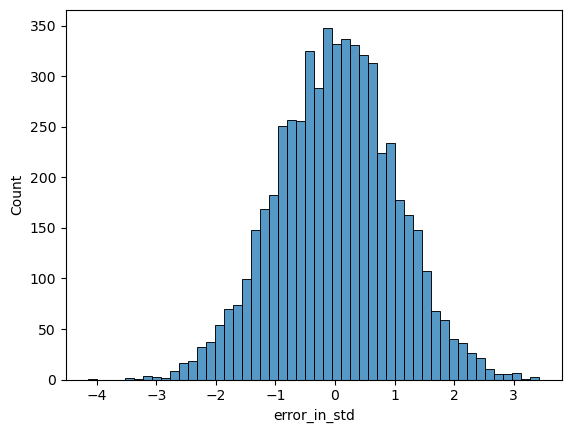

In [90]:
sns.histplot(df['error_in_std'])

# Posterior Predictive (Sampling)

Now we see how the whole distribution compares

array([-22.75000607,   7.69202324,  -1.70205177, ...,  -5.62548331,
        11.29060301,  -5.16908827], shape=(5616,))

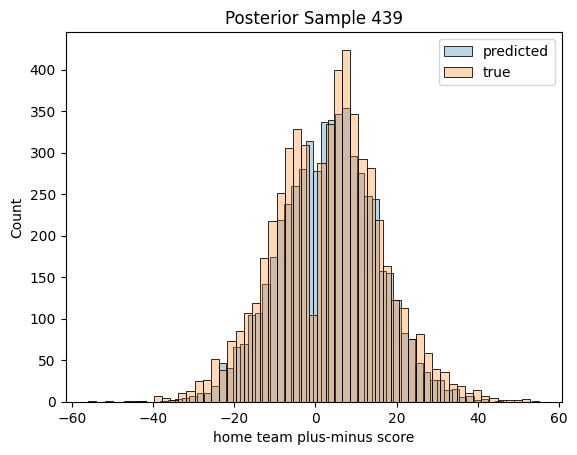

In [47]:
def post_predictive(x=df, posterior_samples=posterior_samples, y=test_y, sample_idx=False):
    K = len(home_cols)  # number of predictors
    betas_cols = [f"beta[{i}]" for i in range(1, K+1)]
    
    sample_idx = sample_idx or np.random.randint(len(posterior_samples))
    row = posterior_samples.iloc[sample_idx]
    betas = row[betas_cols].to_numpy()  # shape (K,)
    alpha = row['alpha']

    X_h = x[home_cols].to_numpy()  # shape (N, K)
    X_a = x[away_cols].to_numpy()  # shape (N, K)

    pred = alpha + X_h @ betas - X_a @ betas  # shape (N,)
    sns.histplot(pred, alpha=.3, label='predicted')
    # pred_samples = np.vectorize(lambda x: np.random.normal(x, row['sigma'], 1))(pred)
    # sns.histplot(pred_samples, alpha=.3, label='pred')
    sns.histplot(test_y['plus_minus_home'], alpha=.3, label='true')
    plt.xlabel('home team plus-minus score')
    plt.title(f"Posterior Sample {sample_idx}")
    plt.legend()
    return pred

post_predictive()

array([-22.70887792,   7.34464836,  -1.63732565, ...,  -5.69296614,
        10.99161826,  -5.18725628], shape=(5616,))

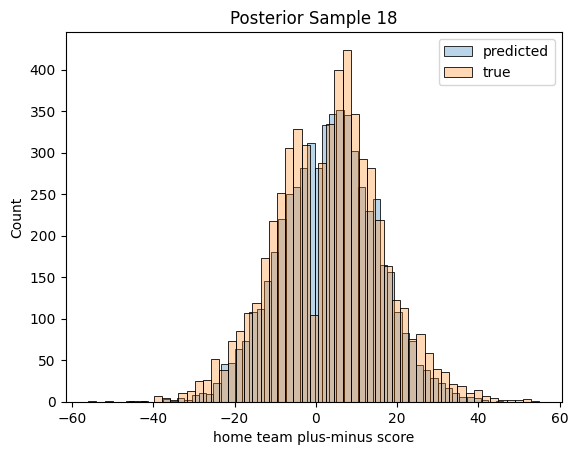

In [40]:
post_predictive()

In [ ]:
# def post_predictive_sampled(x=df, posterior_samples=posterior_samples, y=test_y, sample_idx=False):
#     K = len(home_cols)  # number of predictors
#     betas_cols = [f"beta[{i}]" for i in range(1, K+1)]
#     n = len(test_y)
#     print(type(posterior_samples))
#     posterior_sub_samples = posterior_samples.sample(n=n, replace=True)
#     print(posterior_sub_samples.iloc[0])
#     predictive_samples = []

#     X_h = x[home_cols].to_numpy()  # shape (N, K)
#     X_a = x[away_cols].to_numpy()  # shape (N, K)

#     # sample_idx = sample_idx or np.random.randint(len(posterior_samples))
#     # row = posterior_samples.iloc[sample_idx]
#     for row in posterior_sub_samples:
#         betas = row[betas_cols].to_numpy()  # shape (K,)
#         alpha = row['alpha']

#         sample_row_index = np.random.randint(0, X_h.shape[0])
#         x_h = X_h[sample_row_index]
#         x_a = X_a[sample_row_index]

#         pred_mu = alpha + x_h @ betas - x_a @ betas  # shape (N,)
#         predictive_samples.append(np.random.normal(pred_mu, row['sigma'], 1))

#     sns.histplot(predictive_samples, alpha=.3, label='pred')
#     sns.histplot(test_y['plus_minus_home'], alpha=.3, label='true')
#     plt.title(f"Posterior Sample {sample_idx}")
#     plt.legend()
#     return predictive_samples

# post_predictive_sampled(sample_idx=1260)

<class 'pandas.core.frame.DataFrame'>
alpha           0.136980
beta[1]         0.175758
beta[2]         0.261509
beta[3]         0.190903
beta[4]        -0.246830
beta[5]         1.519859
beta[6]         0.488515
beta[7]         0.140581
beta[8]         0.142513
beta[9]        -1.188205
beta[10]       -0.055687
sigma           6.161665
lp__       -52139.689739
Name: 1127, dtype: float64


TypeError: string indices must be integers, not 'list'

array([-22.48875316,   7.52643516,  -1.63502703, ...,  -5.57830069,
        11.17998483,  -5.08754853], shape=(5616,))

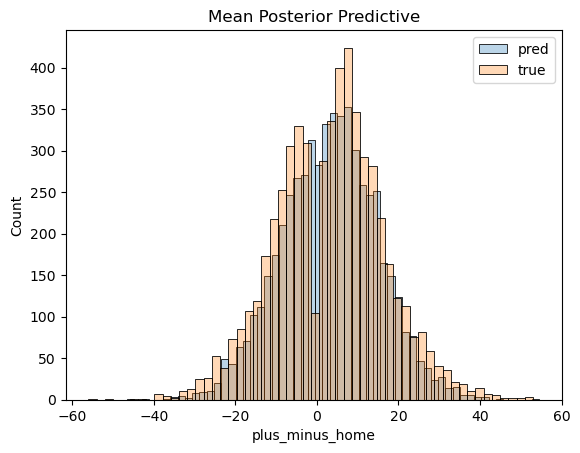

In [92]:
def post_predictive_mean(x=df, posterior_samples=posterior_samples, y=test_y, sample_idx=False):
    K = len(home_cols)  # number of predictors
    betas_cols = [f"beta[{i}]" for i in range(1, K+1)]
    
    betas = posterior_samples[betas_cols].mean().to_numpy()  # shape (K,)
    alpha = posterior_samples['alpha'].mean()

    X_h = x[home_cols].to_numpy()  # shape (N, K)
    X_a = x[away_cols].to_numpy()  # shape (N, K)

    pred = alpha + X_h @ betas - X_a @ betas  # shape (N,)
    sns.histplot(pred, alpha=.3, label='pred')
    sns.histplot(test_y['plus_minus_home'], alpha=.3, label='true')
    plt.title(f"Mean Posterior Predictive") 
    plt.legend()
    return pred

post_predictive_mean()

6.16614271787694


(array([ 24., 159., 457., 584., 445., 210.,  87.,  25.,   6.,   3.]),
 array([6.15987709, 6.1615655 , 6.16325392, 6.16494233, 6.16663075,
        6.16831916, 6.17000757, 6.17169599, 6.1733844 , 6.17507282,
        6.17676123]),
 <BarContainer object of 10 artists>)

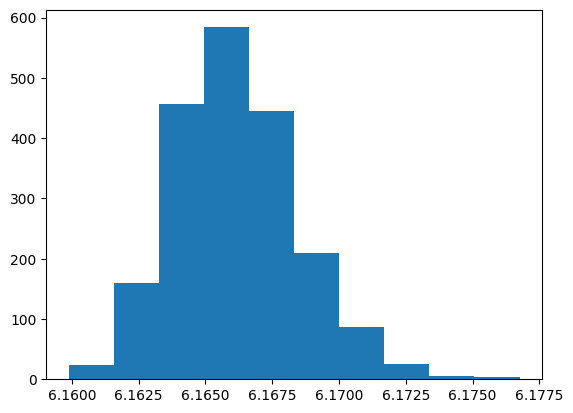

In [ ]:
def calc_rmse(x=df, posterior_samples=posterior_samples, y=test_y, sample_idx=False):
    K = len(home_cols)  # number of predictors
    betas_cols = [f"beta[{i}]" for i in range(1, K+1)]

    sample_idx = sample_idx or np.random.randint(len(posterior_samples))
    row = posterior_samples.iloc[sample_idx]
    betas = row[betas_cols].to_numpy()  # shape (K,)
    alpha = row['alpha']

    X_h = x[home_cols].to_numpy()  # shape (N, K)
    X_a = x[away_cols].to_numpy()  # shape (N, K)

    pred = alpha + X_h @ betas - X_a @ betas  # shape (N,)
    pred = pred.reshape(-1,1)
    errors = y-pred
    squared_errors = errors**2
    mean_squared_errors = np.mean(squared_errors)
    return np.sqrt(mean_squared_errors)

rmses = []
for index, row in posterior_samples.iterrows():
    rmses.append(calc_rmse(sample_idx=index))

print(np.mean(rmses))
plt.hist(rmses)